# Morris Sensitivity Analysis – SnowToSwe

Computes **Elementary Effect (Morris)** indices for all 7 ΔSnow parameters using
**SALib** (Herman & Usher, 2017; Iwanaga et al., 2022).  
Model input: daily HS from 18 Alpsolut stations (Oct 2023 – Jul 2025).  
Output metric: mean NRMSE of modelled SWE vs SNOWPACK SWE, averaged across all valid (station × hydrological year) blocks.

| Parameter | Description | Lower | Default | Upper |
|-----------|-------------|------:|--------:|------:|
| `rho_max` | Maximum snow density [kg/m³] | 300 | 401.3 | 600 |
| `rho_null` | Fresh-snow density [kg/m³] | 50 | 81.2 | 200 |
| `c_ov` | Overburden compaction coefficient | 1e-6 | 5.1e-4 | 1e-3 |
| `k_ov` | Overburden density exponent | 0.01 | 0.38 | 10.0 |
| `k` | Viscosity density exponent | 0.01 | 0.030 | 0.2 |
| `tau` | New-snow threshold [m] | 0.01 | 0.024 | 0.2 |
| `eta_null` | Reference viscosity [Pa·s] | 1e6 | 8.5e6 | 2e7 |

Bounds taken from the DE-calibration search space in `calibration_SNOWPACK/dsnow_parameter_optimization_DE.R`.

In [1]:
import sys, os, io, contextlib, warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
from joblib import Parallel, delayed
from tqdm.auto import tqdm
from SALib.sample import morris as salib_sample
from SALib.analyze import morris as salib_analyze

# ── Project paths ─────────────────────────────────────────────────────────────
ROOT    = Path("/Users/jakobwerkgarner/code/mt_dsnow")
OUT_DIR = ROOT / "par_sens/morris_SNOWPACK"
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "snow_to_swe_master"))

from main import SnowToSwe
from plot_style import apply_style, C, ALPHA, FIG

warnings.filterwarnings("ignore")
apply_style()

# ── Morris settings ────────────────────────────────────────────────────────────
N_TRAJ     = 50    # number of Morris trajectories (≥30 recommended)
NUM_LEVELS = 6     # grid discretisation levels (even number)
N_JOBS     = -1    # parallel workers (-1 = all cores; 1 = sequential)
SEED       = 42

# ── Parameter space (from DE calibration bounds) ───────────────────────────────
PARAM_NAMES  = ["rho_max", "rho_null", "c_ov", "k_ov", "k", "tau", "eta_null"]
PARAM_LATEX  = [r"$\rho_{max}$", r"$\rho_0$", r"$c_{ov}$",
                r"$k_{ov}$",     r"$k$",       r"$\tau$", r"$\eta_0$"]
PARAM_BOUNDS = [
    [300,  600  ],  # rho_max
    [50,   200  ],  # rho_null
    [1e-6, 1e-3 ],  # c_ov
    [0.01, 10.0 ],  # k_ov
    [0.01, 0.2  ],  # k
    [0.01, 0.2  ],  # tau
    [1e6,  2e7  ],  # eta_null
]
K = len(PARAM_NAMES)

# SALib problem definition — used for both sampling and analysis
PROBLEM = {
    'num_vars': K,
    'names':    PARAM_NAMES,
    'bounds':   PARAM_BOUNDS,
}

# One colour per parameter (Okabe-Ito palette via C.CYCLE)
PARAM_COLORS = dict(zip(PARAM_LATEX, C.CYCLE[:K]))

/Users/jakobwerkgarner/miniforge3/envs/MT_dsnow/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1 · Load data & build station×winter task list

In [4]:
DATA_PATH = ROOT / "calibration/calibration_data/SNOWPACK_data/data_18_all/alpsolut_all_daily.nc"

ds = xr.open_dataset(DATA_PATH)

# ── Resample hourly → daily (mean) ────────────────────────────────────────────
ds_daily    = ds.resample(time="1D").mean()
times_daily = pd.to_datetime(ds_daily["time"].values)

# Hydrological year: Sep 1 → Aug 31  (same convention as calibration scripts)
hyd_year_d   = np.where(times_daily.month >= 9, times_daily.year, times_daily.year - 1)
winter_years = np.unique(hyd_year_d)

# ── Build (station, winter) task list ─────────────────────────────────────────
station_names = ds_daily["station"].values
station_tasks = []   # list of (station_name, winter_year, hs_1d, swe_1d)

for stn in station_names:
    hs_full  = ds_daily["HS" ].sel(station=stn).values.astype(float)
    swe_full = ds_daily["SWE"].sel(station=stn).values.astype(float)

    for wy in winter_years:
        mask = hyd_year_d == wy
        hs   = pd.Series(hs_full[mask]).ffill(limit=3).fillna(0).clip(lower=0).values
        swe  = swe_full[mask]

        # Skip blocks with too little snow or too few SWE reference points
        n_valid = int(np.sum(~np.isnan(swe) & (swe > 5)))
        if n_valid < 10 or hs.max() < 0.05:
            continue

        # SnowToSwe requires hs[0] == 0 and hs[-1] == 0
        hs[0] = 0.0;  hs[-1] = 0.0

        station_tasks.append((stn, int(wy), hs, swe))

print(f"Stations           : {len(station_names)}")
print(f"Hydrological years : {list(winter_years)}")
print(f"Valid task blocks  : {len(station_tasks)}  (station × winter)")

Stations           : 18
Hydrological years : [np.int32(2023), np.int32(2024)]
Valid task blocks  : 36  (station × winter)


## 2 · Generate Morris sample (SALib)

In [5]:
# SALib generates N*(k+1) parameter sets arranged as N trajectories of k+1 points.
# optimal_trajectories=None uses the standard random design (Morris 1991).
X_flat = salib_sample.sample(
    PROBLEM,
    N          = N_TRAJ,
    num_levels = NUM_LEVELS,
    seed       = SEED,
)

print(f"Trajectories       : {N_TRAJ}")
print(f"Total model runs   : {len(X_flat)}  ({N_TRAJ} × {K+1})")  # N*(k+1) = 400

Trajectories       : 50
Total model runs   : 400  (50 × 8)


## 3 · Run Morris

In [6]:
def _nrmse_one_block(hs, swe_obs, params):
    """Run SnowToSwe on one (station, winter) block; returns NRMSE or NaN."""
    with contextlib.redirect_stdout(io.StringIO()):
        model    = SnowToSwe(**params)
        swe_pred = model.convert_list(hs.tolist(), timestep=24, verbose=False)
    if swe_pred is None:
        return np.nan

    swe_pred = np.asarray(swe_pred)
    valid    = ~np.isnan(swe_obs) & (swe_obs > 5)
    if valid.sum() < 10:
        return np.nan

    rmse = np.sqrt(np.mean((swe_pred[valid] - swe_obs[valid]) ** 2))
    return float(rmse / swe_obs[valid].mean())


def evaluate_param_set(param_vec, tasks):
    """Mean NRMSE across all valid (station × winter) blocks for one param set."""
    import sys
    sys.path.insert(0, "/Users/jakobwerkgarner/code/mt_dsnow/snow_to_swe_master")

    params  = dict(zip(PARAM_NAMES, param_vec))
    nrmses  = [_nrmse_one_block(hs, swe, params) for _, _, hs, swe in tasks]
    valid   = [v for v in nrmses if not np.isnan(v)]
    return float(np.mean(valid)) if valid else np.nan


# ── Parallel execution ────────────────────────────────────────────────────────
Y_list = []
with tqdm(total=len(X_flat), desc="Morris runs", unit="param-set") as pbar:
    for y in Parallel(n_jobs=N_JOBS, return_as="generator")(
        delayed(evaluate_param_set)(x, station_tasks) for x in X_flat
    ):
        Y_list.append(y)
        pbar.update(1)

Y_flat = np.array(Y_list)

print(f"\nFinished. NaN results: {np.isnan(Y_flat).sum()} / {len(Y_flat)}")
print(f"NRMSE range: [{np.nanmin(Y_flat):.3f}, {np.nanmax(Y_flat):.3f}]")

Morris runs:  23%|██▎       | 93/400 [45:02<6:26:05, 75.46s/param-set] /Users/jakobwerkgarner/code/mt_dsnow/snow_to_swe_master/main.py:257: RuntimeWarning: overflow encountered in exp
  h_dd = x.iloc[0] / (1 + (x.iloc[2] * EARTH_GRAVITATIONAL_ACCELERATION * ts) / self.eta_null * exp(-self.k * x.iloc[1] / x.iloc[0]))
/Users/jakobwerkgarner/code/mt_dsnow/snow_to_swe_master/main.py:257: RuntimeWarning: overflow encountered in exp
  h_dd = x.iloc[0] / (1 + (x.iloc[2] * EARTH_GRAVITATIONAL_ACCELERATION * ts) / self.eta_null * exp(-self.k * x.iloc[1] / x.iloc[0]))
/Users/jakobwerkgarner/code/mt_dsnow/snow_to_swe_master/main.py:292: RuntimeWarning: overflow encountered in exp
  x = ts * EARTH_GRAVITATIONAL_ACCELERATION * swe_hat_d[i] * exp(-self.k * rho_d)  # yesterday
/Users/jakobwerkgarner/code/mt_dsnow/snow_to_swe_master/main.py:299: RuntimeWarning: overflow encountered in exp
  h_dd_cor = np.array(h_d) / (1 + (np.array(swe_hat_d) * EARTH_GRAVITATIONAL_ACCELERATION * ts) / np.array(eta_cor


Finished. NaN results: 0 / 400
NRMSE range: [0.176, 1.025]


## 4 · Compute Morris indices (SALib)

In [7]:
# SALib returns a dict with keys: mu, mu_star, sigma, mu_star_conf
Si = salib_analyze.analyze(
    PROBLEM,
    X_flat,
    Y_flat,
    num_levels      = NUM_LEVELS,
    num_resamples   = 1000,   # bootstrap resamples for mu_star_conf
    print_to_console= False,
    seed            = SEED,
)

results = pd.DataFrame({
    "parameter"   : PARAM_LATEX,
    "name"        : PARAM_NAMES,
    "mu_star"     : Si["mu_star"],
    "mu_star_conf": Si["mu_star_conf"],   # 95 % bootstrap CI half-width
    "mu"          : Si["mu"],
    "sigma"       : Si["sigma"],
}).sort_values("mu_star", ascending=False).reset_index(drop=True)

display(results[["name", "mu_star", "mu_star_conf", "mu", "sigma"]]
        .rename(columns={"name": "parameter", "mu_star": "μ*",
                         "mu_star_conf": "μ* 95%-CI", "mu": "μ", "sigma": "σ"})
        .style.format({"μ*": "{:.4f}", "μ* 95%-CI": "±{:.4f}", "μ": "{:.4f}", "σ": "{:.4f}"})
        .background_gradient(subset="μ*", cmap="YlOrRd"))

,parameter,μ*,μ* 95%-CI,μ,σ
0,rho_null,0.5177,±0.0613,-0.4640,0.3190
1,tau,0.4124,±0.0462,0.4079,0.1805
2,k,0.2682,±0.0958,0.2358,0.3734
3,rho_max,0.0828,±0.0371,0.0243,0.1541
4,eta_null,0.0553,±0.0233,0.0111,0.1006
5,c_ov,0.0346,±0.0121,-0.0288,0.0489
6,k_ov,0.0336,±0.0128,0.0273,0.0503


In [8]:
# ── Save Morris outputs to disk ────────────────────────────────────────────────
np.save(OUT_DIR / "morris_X_flat_SP.npy", X_flat)
np.save(OUT_DIR / "morris_Y_flat_SP.npy", Y_flat)
results.to_csv(OUT_DIR / "morris_results_SP.csv", index=False)
print(f"Saved  X_flat  → {OUT_DIR / 'morris_X_flat_SP.npy'}")
print(f"Saved  Y_flat  → {OUT_DIR / 'morris_Y_flat_SP.npy'}")
print(f"Saved  results → {OUT_DIR / 'morris_results_SP.csv'}")

Saved  X_flat  → /Users/jakobwerkgarner/code/mt_dsnow/par_sens/morris_SNOWPACK/morris_X_flat_SP.npy
Saved  Y_flat  → /Users/jakobwerkgarner/code/mt_dsnow/par_sens/morris_SNOWPACK/morris_Y_flat_SP.npy
Saved  results → /Users/jakobwerkgarner/code/mt_dsnow/par_sens/morris_SNOWPACK/morris_results_SP.csv


## 5 · Plots

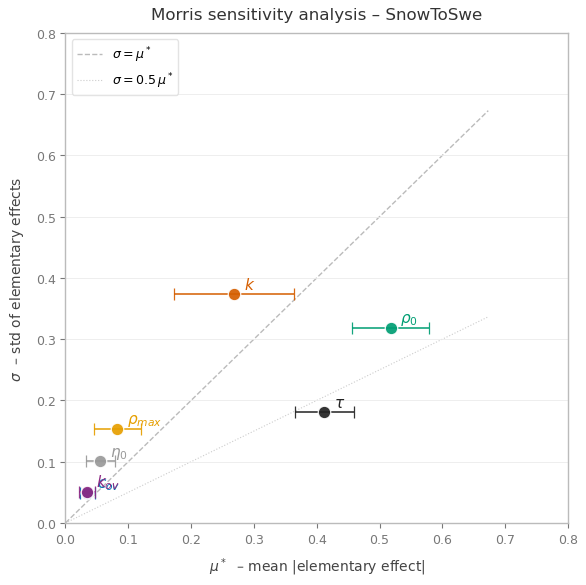

In [17]:
# ── Plot 1: μ* vs σ  (Morris chart) ──────────────────────────────────────────
#
# Parameters above the σ = μ* line have strong interactions / nonlinearity.
# Parameters near the origin are non-influential.

fig, ax = plt.subplots(figsize=(6,  6))

lim = max(results["mu_star"].max(), results["sigma"].max()) * 1.3
ax.plot([0, lim], [0, lim],       ls="--", lw=1.0, color="#BBBBBB", zorder=0, label=r"$\sigma = \mu^*$")
ax.plot([0, lim], [0, 0.5 * lim], ls=":",  lw=0.8, color="#CCCCCC", zorder=0, label=r"$\sigma = 0.5\,\mu^*$")

for _, row in results.iterrows():
    col = PARAM_COLORS[row["parameter"]]
    ax.errorbar(
        row["mu_star"], row["sigma"],
        xerr=row["mu_star_conf"],
        fmt="o", ms=9, color=col, ecolor=col, elinewidth=1.2,
        capsize=4, zorder=4, alpha=0.92,
        markeredgecolor="white", markeredgewidth=0.9,
    )
    ax.annotate(
        row["parameter"],
        xy=(row["mu_star"], row["sigma"]),
        xytext=(7, 4), textcoords="offset points",
        fontsize=11, color=col, fontweight="bold",
    )

ax.set_xlim(0, 0.8)
ax.set_ylim(0, 0.8)
ax.set_xlabel(r"$\mu^*$  – mean $|$elementary effect$|$", labelpad=7)
ax.set_ylabel(r"$\sigma$  – std of elementary effects",   labelpad=7)
ax.set_title("Morris sensitivity analysis – SnowToSwe", pad=10)
ax.legend(loc="upper left", fontsize=9, framealpha=0.8)

plt.tight_layout()
fig.savefig(OUT_DIR / "morris_scatter_SP.png", **FIG.SAVE)
plt.show()

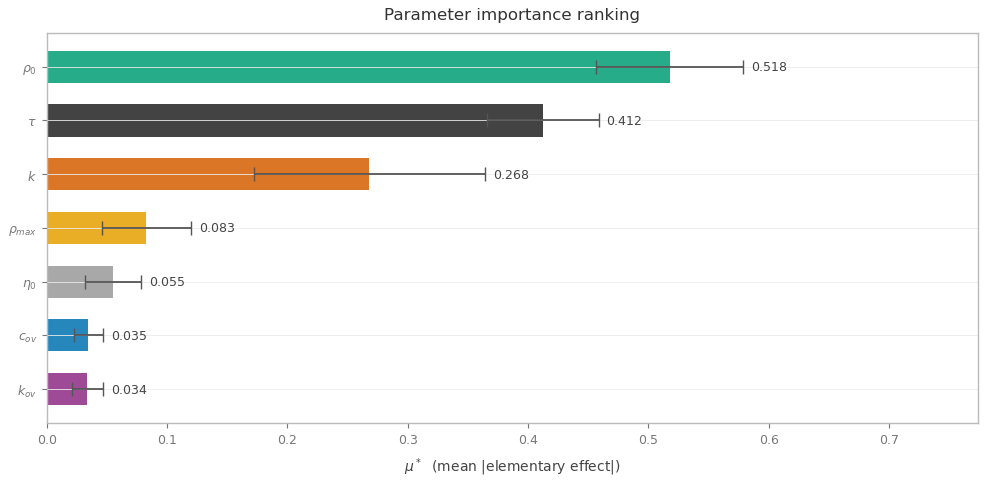

In [18]:
# ── Plot 2: μ* ranking bar chart ──────────────────────────────────────────────

ranked = results.sort_values("mu_star", ascending=True)   # ascending → most important on top

fig, ax = plt.subplots(figsize=FIG.SINGLE)

colors = [PARAM_COLORS[p] for p in ranked["parameter"]]
ax.barh(
    ranked["parameter"], ranked["mu_star"],
    xerr   = ranked["mu_star_conf"],
    color  = colors,
    height = 0.6,
    alpha  = 0.85,
    error_kw = dict(elinewidth=1.3, ecolor="#555555", capsize=5),
)

for _, row in ranked.iterrows():
    ax.text(row["mu_star"] + row["mu_star_conf"] + lim * 0.01,
            row["parameter"], f"{row['mu_star']:.3f}",
            va="center", fontsize=9, color="#444444")

ax.set_xlabel(r"$\mu^*$  (mean $|$elementary effect$|$)", labelpad=7)
ax.set_title("Parameter importance ranking", pad=10)
ax.set_xlim(0, lim * 1.15)

plt.tight_layout()
fig.savefig(OUT_DIR / "morris_ranking_SP.png", **FIG.SAVE)
plt.show()

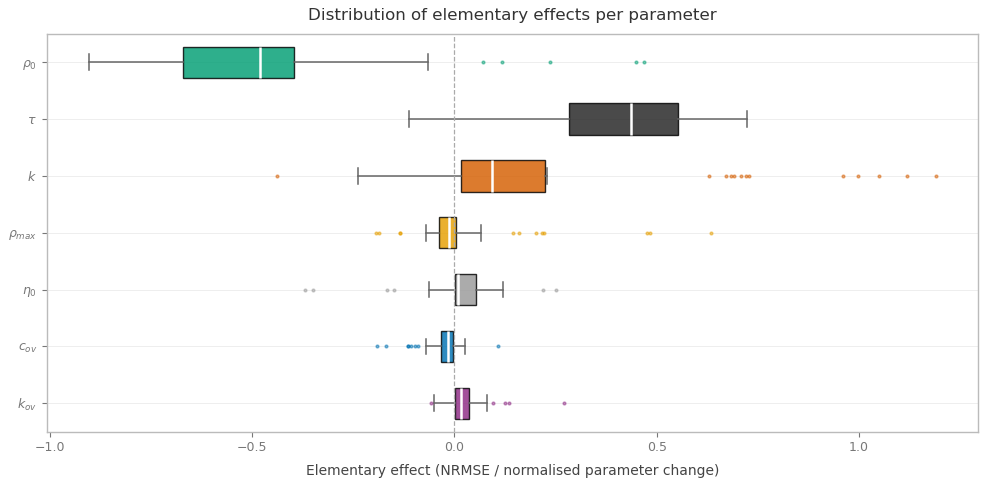

In [19]:
# ── Plot 3: EE distributions (box-plots per parameter) ───────────────────────
#
# SALib does not expose raw EEs, so we recompute them from the trajectory
# structure: consecutive points in each trajectory differ in exactly one
# parameter by one step Δ.  EE = ΔY / (Δx_j / range_j).

lo = np.array([b[0] for b in PARAM_BOUNDS])
hi = np.array([b[1] for b in PARAM_BOUNDS])

X_traj = X_flat.reshape(N_TRAJ, K + 1, K)   # (N, k+1, k)
Y_traj = Y_flat.reshape(N_TRAJ, K + 1)

EE_raw = [[] for _ in range(K)]
for r in range(N_TRAJ):
    for step in range(K):
        diff   = X_traj[r, step + 1] - X_traj[r, step]
        j      = int(np.argmax(np.abs(diff)))
        d_norm = diff[j] / (hi[j] - lo[j])
        if abs(d_norm) > 1e-12:
            EE_raw[j].append((Y_traj[r, step + 1] - Y_traj[r, step]) / d_norm)

order          = results.sort_values("mu_star", ascending=True).index.tolist()
labels_ordered = [results.loc[i, "parameter"] for i in order]
colors_ordered = [PARAM_COLORS[lbl] for lbl in labels_ordered]

name_to_idx = {n: i for i, n in enumerate(PARAM_NAMES)}
ee_data     = [EE_raw[name_to_idx[results.loc[i, "name"]]] for i in order]

fig, ax = plt.subplots(figsize=FIG.SINGLE)

bp = ax.boxplot(
    ee_data,
    vert        = False,
    labels      = labels_ordered,
    patch_artist= True,
    widths      = 0.55,
    flierprops  = dict(marker=".", markersize=4, alpha=0.5),
    medianprops = dict(color="white", linewidth=1.8),
)
for patch, col in zip(bp["boxes"], colors_ordered):
    patch.set_facecolor(col);  patch.set_alpha(0.82)
for whisker in bp["whiskers"] + bp["caps"]:
    whisker.set_color("#666666");  whisker.set_linewidth(1.1)
for flier, col in zip(bp["fliers"], colors_ordered):
    flier.set_markerfacecolor(col);  flier.set_markeredgecolor(col)

ax.axvline(0, color="#AAAAAA", lw=0.9, ls="--")
ax.set_xlabel("Elementary effect (NRMSE / normalised parameter change)", labelpad=7)
ax.set_title("Distribution of elementary effects per parameter", pad=10)

plt.tight_layout()
fig.savefig(OUT_DIR / "morris_ee_distributions_SP.png", **FIG.SAVE)
plt.show()